## Module 4: Time Series Forecasting Using ARIMA

## NovaMart AI Retail Intelligence Platform

### Overview

Sales forecasting is one of the most important applications of retail analytics. Accurate forecasts enable businesses to optimize inventory management, improve procurement planning, allocate resources efficiently, and support strategic decision-making.

This notebook develops a classical time-series forecasting model using the **Autoregressive Integrated Moving Average (ARIMA)** methodology. Daily sales revenue is extracted from the retail transaction dataset and analyzed using the Box–Jenkins forecasting framework.

The workflow includes exploratory time-series analysis, stationarity testing, differencing, ARIMA model development, forecasting, residual diagnostics, and future sales prediction.

## Objectives

This notebook aims to:

- Build a daily revenue time series
- Explore historical sales behaviour
- Develop a persistence baseline forecast
- Test stationarity using the Augmented Dickey-Fuller (ADF) test
- Apply differencing where necessary
- Identify appropriate ARIMA parameters
- Train and evaluate ARIMA models
- Forecast future daily revenue
- Generate business recommendations

In [2]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)

from statsmodels.graphics.gofplots import qqplot

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

### Load Dataset

In [3]:
#Load Dataset

retail = pd.read_csv("retail_master_dataset.csv")

### Convert Date Columns

In [4]:
date_columns = [

    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"

]

for col in date_columns:

    retail[col] = pd.to_datetime(retail[col])

# Exploratory Analysis

Before building forecasting models, it is important to understand the behaviour of daily sales.

This section investigates:

- Daily revenue trend
- 7-day moving average
- 30-day moving average
- Revenue distribution
- Monthly seasonality
- Day-of-week sales
- Weekend versus weekday sales

These analyses provide valuable insights into trends, seasonality, and customer purchasing behaviour that will guide feature engineering and model development.

## Daily Revenue Trend

### Daily Revenue Aggregation

Revenue is aggregated at the daily level by summing the payment value of all transactions completed on each day.

In [5]:
daily_sales = (

    retail

    .groupby(

        pd.Grouper(

            key="order_purchase_timestamp",

            freq="D"

        )

    )["payment_value"]

    .sum()

    .reset_index()

)

daily_sales.columns = [

    "Date",

    "Revenue"

]

daily_sales.head()

,Date,Revenue
0,2016-09-04,272.46
1,2016-09-05,75.06
2,2016-09-06,0.00
3,2016-09-07,0.00
4,2016-09-08,0.00


In [6]:
daily_sales.tail(15)

,Date,Revenue
715,2018-08-20,48283.31
716,2018-08-21,34085.45
717,2018-08-22,29452.60
718,2018-08-23,22317.68
719,2018-08-24,14322.22
720,2018-08-25,12768.89
721,2018-08-26,10496.35
722,2018-08-27,6720.78
723,2018-08-28,5012.70
724,2018-08-29,4262.66


In [7]:
daily_sales.shape

(730, 2)

In [8]:
daily_sales.describe()

,Revenue
count,730.000000
mean,27909.021425
std,22591.448780
min,0.000000
25%,11614.630000
50%,25776.165000
75%,41177.282500
max,257690.800000


### Revenue Trend

The daily revenue trend provides an overview of sales performance throughout the observation period. Daily fluctuations may be influenced by customer purchasing behaviour, promotional campaigns, weekends, holidays, and seasonal demand.

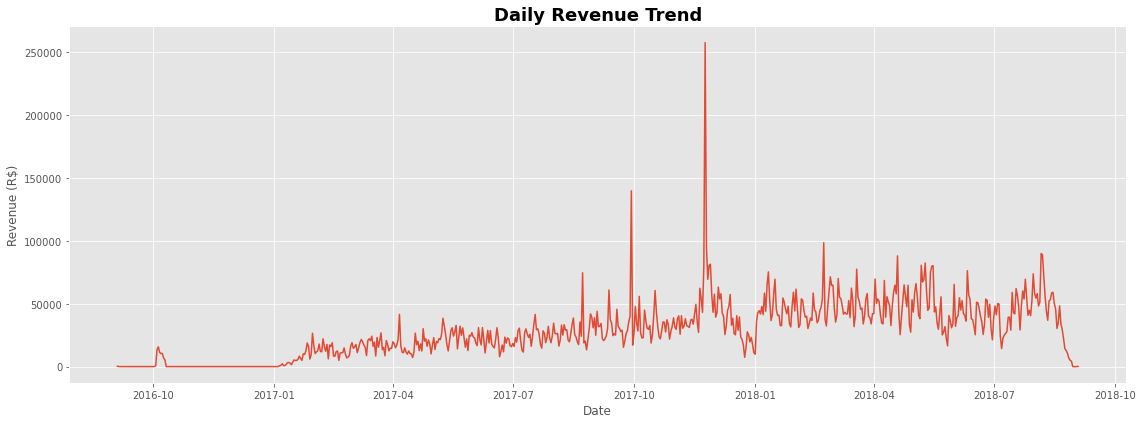

In [9]:
plt.figure(figsize=(16,6))

plt.plot(

    daily_sales["Date"],

    daily_sales["Revenue"],

    linewidth=1.5

)

plt.title(
    "Daily Revenue Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Revenue (R$)")

plt.tight_layout()

plt.show()

### Create Moving Averages
A 7-day moving average is calculated to smooth short-term fluctuations and highlight longer-term trends.

In [12]:
daily_sales["MA_7"] = (
    daily_sales["Revenue"]
    .rolling(7)
    .mean()
)

daily_sales["MA_30"] = (
    daily_sales["Revenue"]
    .rolling(30)
    .mean()
)

### Revenue Trend with Moving Averages

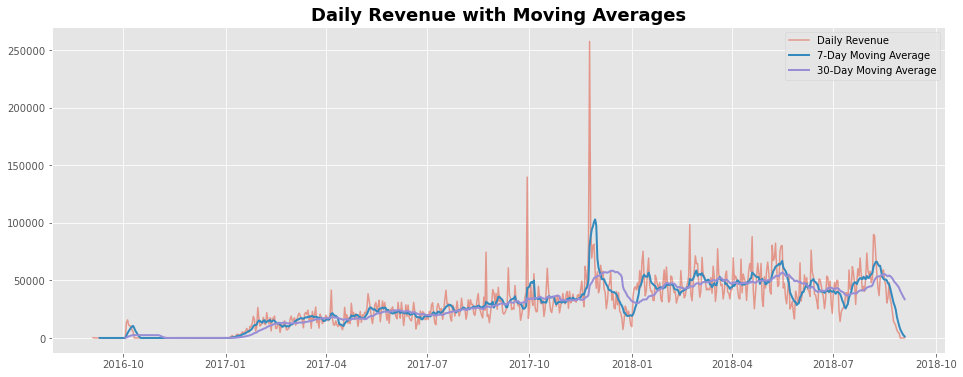

In [13]:
plt.figure(figsize=(16,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Revenue"],
    alpha=0.5,
    label="Daily Revenue"
)

plt.plot(
    daily_sales["Date"],
    daily_sales["MA_7"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.plot(
    daily_sales["Date"],
    daily_sales["MA_30"],
    linewidth=2,
    label="30-Day Moving Average"
)

plt.legend()

plt.title(
    "Daily Revenue with Moving Averages",
    fontsize=18,
    fontweight="bold"
)

plt.show()

### Revenue Distribution
-Histogram

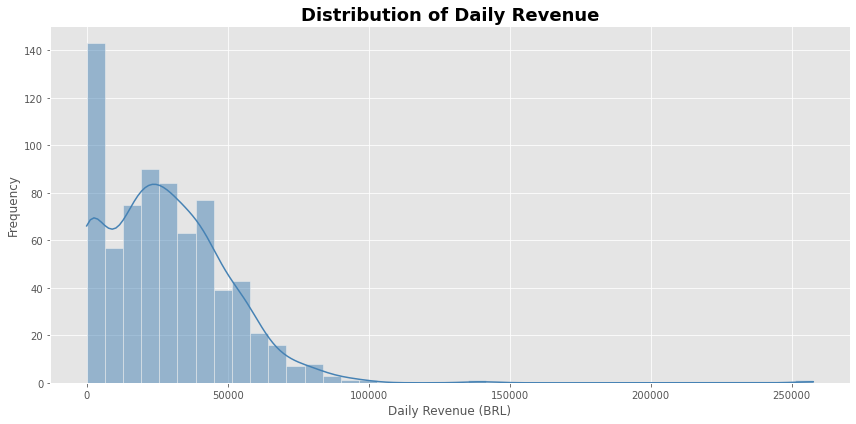

In [25]:
plt.figure(figsize=(12,6))

sns.histplot(
    daily_sales["Revenue"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title(
    "Distribution of Daily Revenue",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Daily Revenue (BRL)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

The 7-day moving average smooths short-term fluctuations and highlights weekly sales patterns, while the 30-day moving average captures the longer-term sales trend. Together, they provide a clearer understanding of underlying business performance.

### Revenue Distribution
- Boxplot

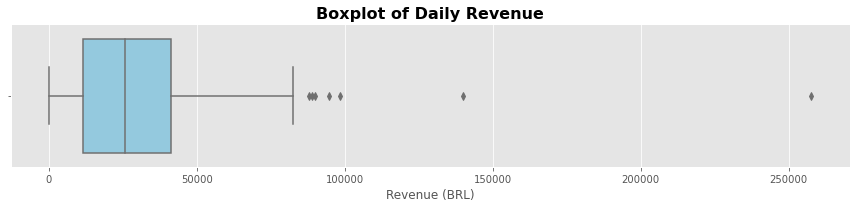

In [26]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=daily_sales["Revenue"],
    color="skyblue"
)

plt.title(
    "Boxplot of Daily Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Revenue (BRL)")

plt.tight_layout()

plt.show()

## Seasonality Analysis

- Revenue by month
- Revenue by weekday
- Weekend vs weekday
- Revenue distribution

# Seasonality Analysis

Understanding seasonal patterns in retail sales is essential for accurate forecasting and business planning.

This section explores:

- Revenue by month
- Revenue by day of the week
- Weekend versus weekday performance
- Daily revenue distribution

These analyses help identify recurring sales patterns and customer purchasing behaviour.

## Monthly Seasonality

In [16]:
# ==========================================================
# Revenue by Month
# ==========================================================

daily_sales["Month_Name"] = daily_sales["Date"].dt.month_name()

daily_sales["Month_Number"] = daily_sales["Date"].dt.month

In [18]:
monthly_revenue = (

    daily_sales

    .groupby(

        ["Month_Number", "Month_Name"]

    )["Revenue"]

    .sum()

    .reset_index()

)

monthly_revenue = monthly_revenue.sort_values("Month_Number")

monthly_revenue.head(20)

,Month_Number,Month_Name,Revenue
0,1,January,1603907.50
1,2,February,1663086.06
2,3,March,2010799.59
3,4,April,2005599.06
4,5,May,2235159.29
5,6,June,1900954.34
6,7,July,2094810.21
7,8,August,2105057.38
8,9,September,1022148.92
9,10,October,1099031.91


The revenue distribution illustrates the variability of daily sales and highlights unusually high- or low-revenue days. These outliers may correspond to holidays, promotional campaigns, or exceptional business events.

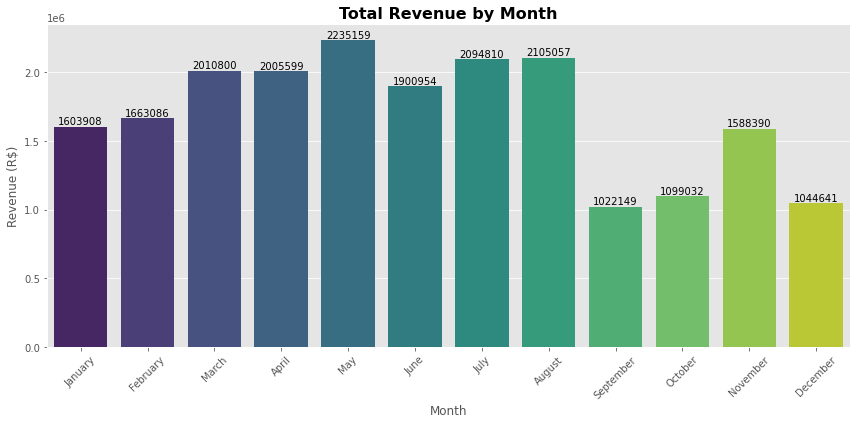

In [19]:
plt.figure(figsize=(12,6))

ax = sns.barplot(

    data=monthly_revenue,

    x="Month_Name",

    y="Revenue",

    palette="viridis"

)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f"
    )

plt.title(
    "Total Revenue by Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")

plt.ylabel("Revenue (R$)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Interpretation

The monthly revenue analysis reveals clear seasonal variations in customer purchasing behaviour throughout the observation period.

**May** generated the highest cumulative revenue (approximately **R$2.24 million**), followed by **August (R$2.11 million)**, **July (R$2.09 million)**, **March (R$2.01 million)**, and **April (R$2.01 million)**. These months represent peak sales periods and may reflect seasonal demand, promotional activities, or increased consumer spending.

In contrast, **October**, **December**, and **September** recorded comparatively lower cumulative revenue. However, September should be interpreted with caution because the dataset contains incomplete records for this month. Likewise, the lower revenue observed in some months may be influenced by differences in the number of recorded business days rather than actual customer demand.

Overall, the results indicate that sales are not uniformly distributed throughout the year, suggesting the presence of seasonal purchasing patterns that should be incorporated into demand forecasting and inventory planning.

### Business Insights

The seasonal revenue pattern provides several actionable business insights:

- Inventory levels should be increased before high-revenue months such as **March**, **April**, **May**, **July**, and **August** to reduce stock shortages.
- Marketing campaigns and promotional activities can be strategically scheduled before peak demand periods to maximize sales.
- Procurement planning should account for seasonal fluctuations by increasing supplier orders ahead of high-demand months.
- Staffing requirements for customer service, warehousing, and logistics should be adjusted during peak sales periods to maintain service quality.
- Lower-revenue months provide an opportunity to introduce promotional campaigns, clearance sales, or customer engagement initiatives to stimulate demand.

### Instead of plotting total revenue by month, plot the average daily revenue for each calendar month.

In [20]:
monthly_avg = (

    daily_sales

    .groupby(["Month_Number", "Month_Name"])

    .agg(

        Total_Revenue=("Revenue", "sum"),

        Average_Daily_Revenue=("Revenue", "mean"),

        Number_of_Days=("Revenue", "count")

    )

    .reset_index()

    .sort_values("Month_Number")

)

monthly_avg

,Month_Number,Month_Name,Total_Revenue,Average_Daily_Revenue,Number_of_Days
0,1,January,1603907.50,25869.475806,62
1,2,February,1663086.06,29697.965357,56
2,3,March,2010799.59,32432.251452,62
3,4,April,2005599.06,33426.651000,60
4,5,May,2235159.29,36050.956290,62
5,6,June,1900954.34,31682.572333,60
6,7,July,2094810.21,33787.261452,62
7,8,August,2105057.38,33952.538387,62
8,9,September,1022148.92,17035.815333,60
9,10,October,1099031.91,17726.321129,62


In [ ]:
Average_Daily_Revenue

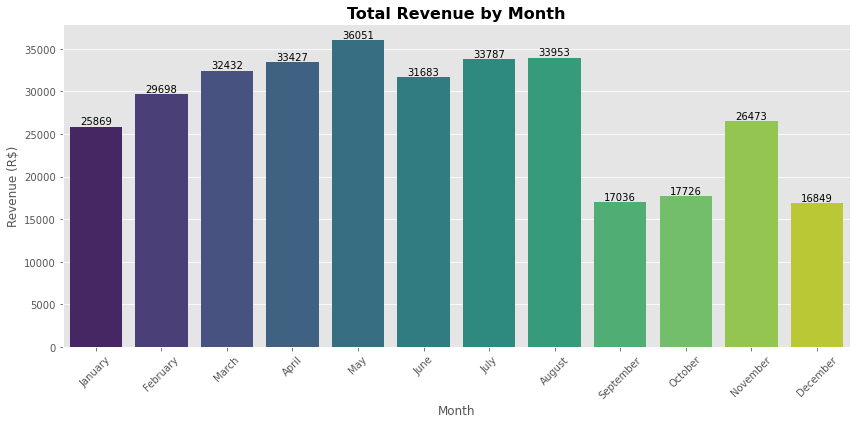

In [23]:
plt.figure(figsize=(12,6))

ax = sns.barplot(

    data=monthly_avg,

    x="Month_Name",

    y="Average_Daily_Revenue",

    palette="viridis"

)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f"
    )

plt.title(
    "Total Revenue by Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")

plt.ylabel("Revenue (R$)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# Monthly Seasonality
# ==========================================================

daily_sales["Month"] = daily_sales["Date"].dt.month_name()

daily_sales["Month_No"] = daily_sales["Date"].dt.month


daily_sales["Month_Name"] = daily_sales["Date"].dt.month_name()

daily_sales["Month_Number"] = daily_sales["Date"].dt.month

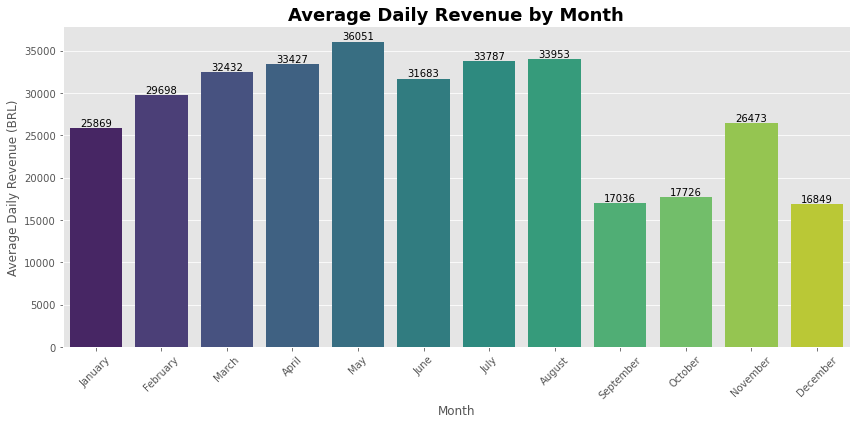

In [30]:

plt.figure(figsize=(12,6))

ax = sns.barplot(

    data=monthly_avg,

    x="Month_Name",

    y="Average_Daily_Revenue",

    palette="viridis"

)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title(
    "Average Daily Revenue by Month",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Daily Revenue (BRL)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Average daily revenue varies across the calendar year, indicating seasonal purchasing patterns. Months with consistently higher average daily sales represent periods of increased customer demand and should be considered during inventory and procurement planning.

### Day-of-Week Sales

In [31]:
###Day-of-Week Sales
daily_sales["Weekday"] = daily_sales["Date"].dt.day_name()

In [32]:
weekday_order = [

    "Monday",

    "Tuesday",

    "Wednesday",

    "Thursday",

    "Friday",

    "Saturday",

    "Sunday"

]

weekday_sales = (

    daily_sales

    .groupby("Weekday")

    .agg(

        Average_Daily_Revenue=("Revenue","mean")

    )

    .reindex(weekday_order)

    .reset_index()

)

weekday_sales

,Weekday,Average_Daily_Revenue
0,Monday,31642.923524
1,Tuesday,31926.347692
2,Wednesday,30457.130096
3,Thursday,29871.735673
4,Friday,29097.421635
5,Saturday,20680.944808
6,Sunday,21710.346286


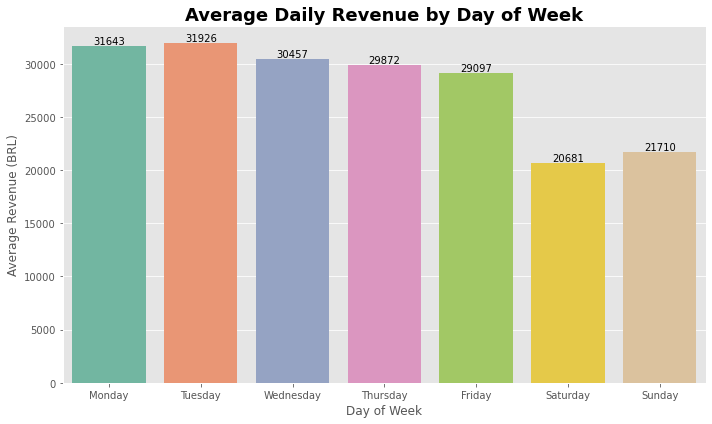

In [33]:
plt.figure(figsize=(10,6))

ax = sns.barplot(

    data=weekday_sales,

    x="Weekday",

    y="Average_Daily_Revenue",

    palette="Set2"

)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title(
    "Average Daily Revenue by Day of Week",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Revenue (BRL)")

plt.tight_layout()

plt.show()

Revenue differs across weekdays, reflecting variations in customer shopping behaviour. Identifying the strongest sales days enables more effective workforce scheduling, promotional planning, and logistics management.

### Weekend vs Weekday Revenue 

In [34]:
#Weekend vs Weekday Revenue
daily_sales["Weekend"] = np.where(

    daily_sales["Date"].dt.dayofweek >= 5,

    "Weekend",

    "Weekday"

)

In [35]:
weekend_sales = (

    daily_sales

    .groupby("Weekend")

    .agg(

        Average_Daily_Revenue=("Revenue","mean")

    )

    .reset_index()

)

weekend_sales

,Weekend,Average_Daily_Revenue
0,Weekday,30601.115202
1,Weekend,21198.108230


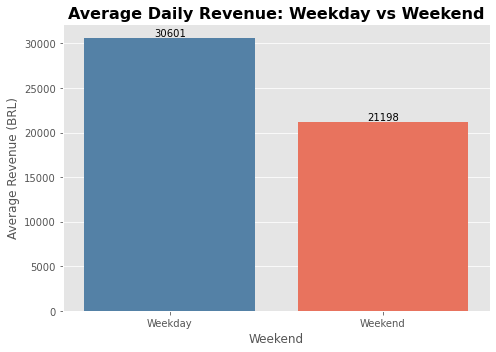

In [37]:
plt.figure(figsize=(7,5))

ax = sns.barplot(

    data=weekend_sales,

    x="Weekend",

    y="Average_Daily_Revenue",

    palette=["steelblue","tomato"]

)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title(
    "Average Daily Revenue: Weekday vs Weekend",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Average Revenue (BRL)")

plt.tight_layout()

plt.show()

Comparing weekday and weekend sales provides insights into customer shopping habits. These findings can inform staffing decisions, promotional scheduling, and delivery capacity planning.

# Feature Engineering

Machine learning algorithms cannot directly learn from dates. Therefore, a comprehensive set of temporal and historical features is engineered from the daily revenue time series.

The engineered features fall into three categories:

- Calendar Features
- Lag Features
- Rolling Window Statistics

These features capture seasonality, temporal trends, and short- and long-term sales behaviour, enabling more accurate revenue forecasting.

### Calendar Features

In [38]:

# ==========================================================
# Calendar Features
# ==========================================================

daily_sales["Year"] = daily_sales["Date"].dt.year

daily_sales["Month"] = daily_sales["Date"].dt.month

daily_sales["Quarter"] = daily_sales["Date"].dt.quarter

daily_sales["Week"] = daily_sales["Date"].dt.isocalendar().week.astype(int)

daily_sales["Day"] = daily_sales["Date"].dt.day

daily_sales["DayOfWeek"] = daily_sales["Date"].dt.dayofweek

In [39]:
#Weekend Indicator
daily_sales["Weekend"] = np.where(
    daily_sales["DayOfWeek"] >= 5,
    1,
    0
)

In [40]:
#Check Calendar Features
daily_sales[
    [
        "Date",
        "Year",
        "Month",
        "Quarter",
        "Week",
        "Day",
        "DayOfWeek",
        "Weekend"
    ]
].head()

,Date,Year,Month,Quarter,Week,Day,DayOfWeek,Weekend
0,2016-09-04,2016,9,3,35,4,6,1
1,2016-09-05,2016,9,3,36,5,0,0
2,2016-09-06,2016,9,3,36,6,1,0
3,2016-09-07,2016,9,3,36,7,2,0
4,2016-09-08,2016,9,3,36,8,3,0


In [41]:
daily_sales["Weekend"].unique()

array([1, 0])

## Lag Features

Lag features represent revenue from previous days.

These variables allow the forecasting model to learn temporal dependencies and recent sales behaviour.

In [42]:
# ==========================================================
# Lag Features
# ==========================================================

lags = [1, 2, 3, 7, 14, 30]

for lag in lags:

    daily_sales[f"Lag_{lag}"] = (
        daily_sales["Revenue"]
        .shift(lag)
    )

In [43]:
daily_sales[
    [
        "Revenue",
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Lag_7",
        "Lag_14",
        "Lag_30"
    ]
].head(35)

,Revenue,Lag_1,Lag_2,Lag_3,Lag_7,Lag_14,Lag_30
0,272.46,NaN,NaN,NaN,NaN,NaN,NaN
1,75.06,272.46,NaN,NaN,NaN,NaN,NaN
2,0.00,75.06,272.46,NaN,NaN,NaN,NaN
3,0.00,0.00,75.06,272.46,NaN,NaN,NaN
4,0.00,0.00,0.00,75.06,NaN,NaN,NaN
5,0.00,0.00,0.00,0.00,NaN,NaN,NaN
6,0.00,0.00,0.00,0.00,NaN,NaN,NaN
7,0.00,0.00,0.00,0.00,272.46,NaN,NaN
8,0.00,0.00,0.00,0.00,75.06,NaN,NaN
9,0.00,0.00,0.00,0.00,0.00,NaN,NaN


## Rolling Window Statistics

Rolling window statistics summarize recent revenue behaviour and help the model identify local trends and volatility.

The following rolling features are computed:

- 7-Day Moving Average
- 14-Day Moving Average
- 30-Day Moving Average
- 7-Day Rolling Standard Deviation
- 30-Day Rolling Standard Deviation

In [44]:
# ==========================================================
# Rolling Mean Features
# ==========================================================

windows = [7, 14, 30]

for window in windows:

    daily_sales[f"RollingMean{window}"] = (

        daily_sales["Revenue"]

        .rolling(window)

        .mean()

    )

In [45]:
# ==========================================================
# Rolling Standard Deviation Features
# ==========================================================

std_windows = [7, 30]

for window in std_windows:

    daily_sales[f"RollingStd{window}"] = (

        daily_sales["Revenue"]

        .rolling(window)

        .std()

    )

### Check Missing Values

The lag and rolling features naturally create missing values at the beginning of the time series.

In [46]:
daily_sales.isnull().sum()

Date              0
Revenue           0
MA_7              6
MA_30            29
Month_Name        0
Month_Number      0
Weekday           0
Weekend           0
Year              0
Month             0
Quarter           0
Week              0
Day               0
DayOfWeek         0
Lag_1             1
Lag_2             2
Lag_3             3
Lag_7             7
Lag_14           14
Lag_30           30
RollingMean7      6
RollingMean14    13
RollingMean30    29
RollingStd7       6
RollingStd30     29
dtype: int64

### Remove Missing Values

In [47]:
### Remove Missing Values
daily_sales = (

    daily_sales

    .dropna()

    .reset_index(drop=True)

)

In [48]:
daily_sales.head()

,Date,Revenue,MA_7,MA_30,Month_Name,Month_Number,Weekday,Weekend,Year,Month,Quarter,Week,Day,DayOfWeek,Lag_1,Lag_2,Lag_3,Lag_7,Lag_14,Lag_30,RollingMean7,RollingMean14,RollingMean30,RollingStd7,RollingStd30
0,2016-10-04,13456.14,2022.945714,474.522667,October,10,Tuesday,0,2016,10,4,40,4,1,595.14,109.34,0.00,0.0,0.0,272.46,2022.945714,1011.472857,474.522667,5046.247533,2454.301865
1,2016-10-05,15753.29,4273.415714,997.130333,October,10,Wednesday,0,2016,10,4,40,5,2,13456.14,595.14,109.34,0.0,0.0,75.06,4273.415714,2136.707857,997.130333,7091.843006,3712.847821
2,2016-10-06,11312.51,5889.488571,1374.214000,October,10,Thursday,0,2016,10,4,40,6,3,15753.29,13456.14,595.14,0.0,0.0,0.00,5889.488571,2944.744286,1374.214000,7243.046659,4156.087995
3,2016-10-07,10381.31,7372.532857,1720.257667,October,10,Friday,0,2016,10,4,40,7,4,11312.51,15753.29,13456.14,0.0,0.0,0.00,7372.532857,3686.266429,1720.257667,6890.389335,4458.876784
4,2016-10-08,10505.11,8873.262857,2070.428000,October,10,Saturday,1,2016,10,4,40,8,5,10381.31,11312.51,15753.29,0.0,0.0,0.00,8873.262857,4436.631429,2070.428000,6117.710032,4723.753801


### Verify Dataset

In [49]:
### Verify Dataset
daily_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           700 non-null    datetime64[ns]
 1   Revenue        700 non-null    float64       
 2   MA_7           700 non-null    float64       
 3   MA_30          700 non-null    float64       
 4   Month_Name     700 non-null    object        
 5   Month_Number   700 non-null    int64         
 6   Weekday        700 non-null    object        
 7   Weekend        700 non-null    int32         
 8   Year           700 non-null    int64         
 9   Month          700 non-null    int64         
 10  Quarter        700 non-null    int64         
 11  Week           700 non-null    int32         
 12  Day            700 non-null    int64         
 13  DayOfWeek      700 non-null    int64         
 14  Lag_1          700 non-null    float64       
 15  Lag_2          700 non-

### Engineered Features

In [51]:
### Engineered Features
engineered_features = [

    "Year",
    "Month",
    "Quarter",
    "Week",
    "Day",
    "DayOfWeek",
    "Weekend",

    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Lag_30",

    "RollingMean7",
    "RollingMean14",
    "RollingMean30",

    "RollingStd7",
    "RollingStd30"

]


In [52]:
print(engineered_features)

['Year', 'Month', 'Quarter', 'Week', 'Day', 'DayOfWeek', 'Weekend', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_30', 'RollingMean7', 'RollingMean14', 'RollingMean30', 'RollingStd7', 'RollingStd30']


### Preview the Final Dataset

In [53]:
### Preview the Final Dataset
daily_sales[

    [

        "Date",
        "Revenue"

    ] + engineered_features

].head()

,Date,Revenue,Year,Month,Quarter,Week,Day,DayOfWeek,Weekend,Lag_1,Lag_2,Lag_3,Lag_7,Lag_14,Lag_30,RollingMean7,RollingMean14,RollingMean30,RollingStd7,RollingStd30
0,2016-10-04,13456.14,2016,10,4,40,4,1,0,595.14,109.34,0.00,0.0,0.0,272.46,2022.945714,1011.472857,474.522667,5046.247533,2454.301865
1,2016-10-05,15753.29,2016,10,4,40,5,2,0,13456.14,595.14,109.34,0.0,0.0,75.06,4273.415714,2136.707857,997.130333,7091.843006,3712.847821
2,2016-10-06,11312.51,2016,10,4,40,6,3,0,15753.29,13456.14,595.14,0.0,0.0,0.00,5889.488571,2944.744286,1374.214000,7243.046659,4156.087995
3,2016-10-07,10381.31,2016,10,4,40,7,4,0,11312.51,15753.29,13456.14,0.0,0.0,0.00,7372.532857,3686.266429,1720.257667,6890.389335,4458.876784
4,2016-10-08,10505.11,2016,10,4,40,8,5,1,10381.31,11312.51,15753.29,0.0,0.0,0.00,8873.262857,4436.631429,2070.428000,6117.710032,4723.753801


### Save the Engineered Dataset

In [55]:
### Save the Engineered Dataset
daily_sales.to_csv(
    "daily_sales_features.csv",
    index=False
)

print("Engineered daily sales dataset saved successfully.")

Engineered daily sales dataset saved successfully.


## Correlation Analysis

Correlation heatmap of engineered features.

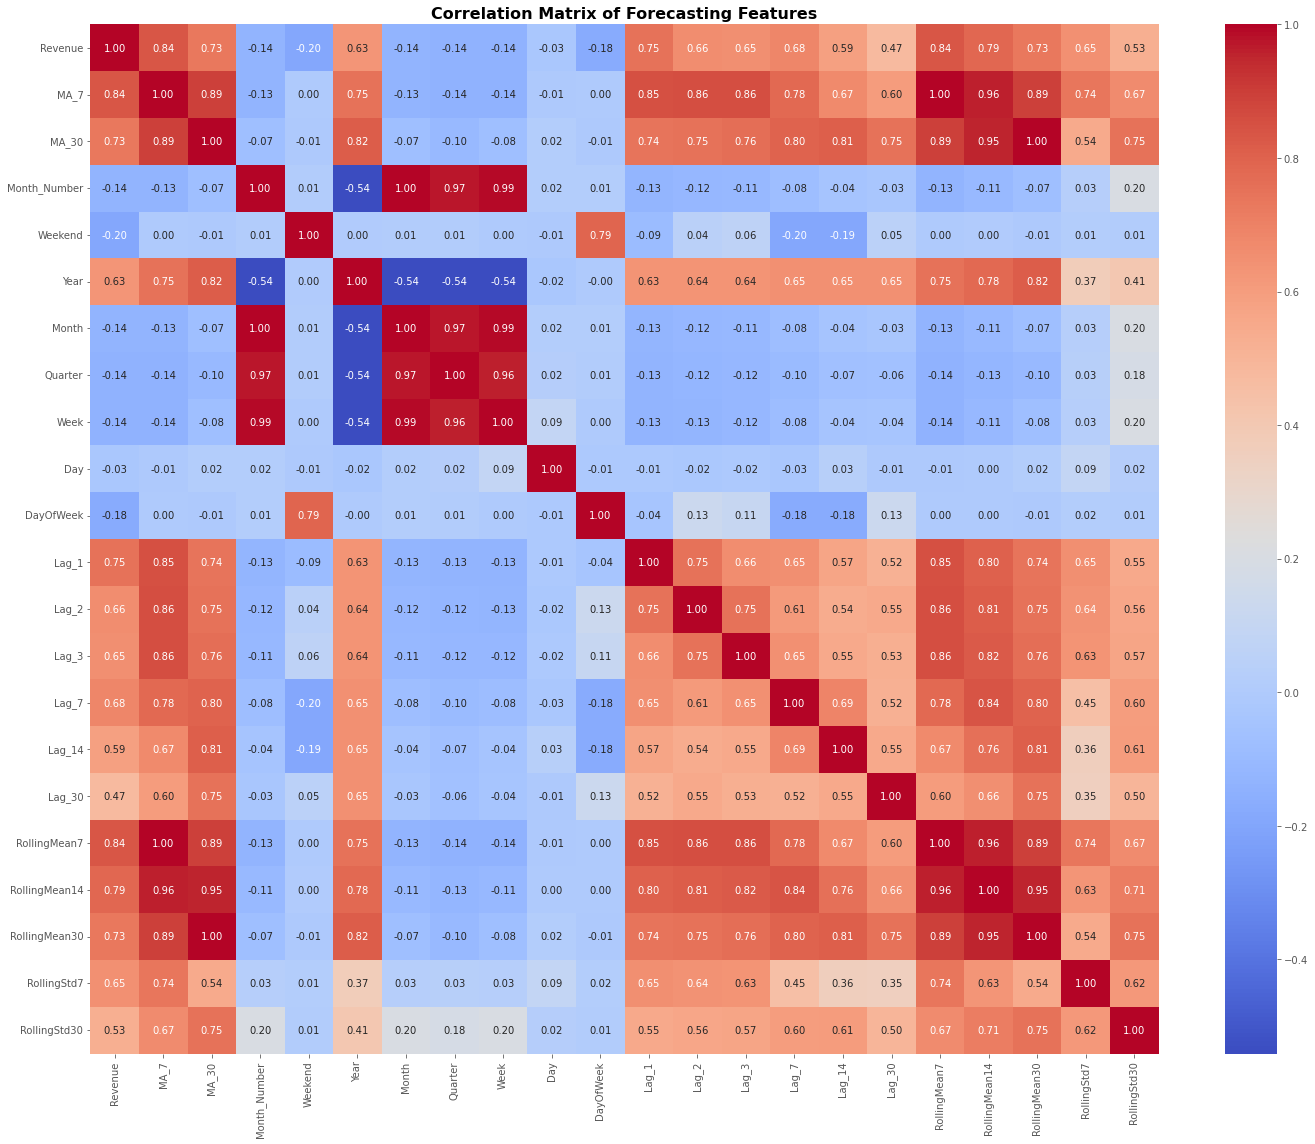

In [57]:
# Select only numeric columns
corr_matrix = daily_sales.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(20,16))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Forecasting Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Prepare the Machine Learning Dataset

The engineered time-series features are now organized into a feature matrix (**X**) and a target variable (**y**).

- **X (Feature Matrix):** Historical sales patterns and calendar-based variables used for prediction.
- **y (Target Variable):** Daily revenue to be forecast.

These datasets will be used to train and evaluate machine learning forecasting models.

In [58]:
# ==========================================================
# Feature Matrix (X)
# ==========================================================

feature_columns = [

    # Calendar Features
    "Year",
    "Month",
    "Quarter",
    "Week",
    "Day",
    "DayOfWeek",
    "Weekend",

    # Lag Features
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Lag_30",

    # Rolling Statistics
    "RollingMean7",
    "RollingMean14",
    "RollingMean30",
    "RollingStd7",
    "RollingStd30"

]

X = daily_sales[feature_columns]

In [59]:
# ==========================================================
# Target Variable (y)
# ==========================================================

y = daily_sales["Revenue"]

### Verify Dataset Dimensions

In [60]:
### Verify Dataset Dimensions
print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape : (700, 18)
Target Variable Shape: (700,)


In [61]:
#Display Feature Matrix
X.head()

,Year,Month,Quarter,Week,Day,DayOfWeek,Weekend,Lag_1,Lag_2,Lag_3,Lag_7,Lag_14,Lag_30,RollingMean7,RollingMean14,RollingMean30,RollingStd7,RollingStd30
0,2016,10,4,40,4,1,0,595.14,109.34,0.00,0.0,0.0,272.46,2022.945714,1011.472857,474.522667,5046.247533,2454.301865
1,2016,10,4,40,5,2,0,13456.14,595.14,109.34,0.0,0.0,75.06,4273.415714,2136.707857,997.130333,7091.843006,3712.847821
2,2016,10,4,40,6,3,0,15753.29,13456.14,595.14,0.0,0.0,0.00,5889.488571,2944.744286,1374.214000,7243.046659,4156.087995
3,2016,10,4,40,7,4,0,11312.51,15753.29,13456.14,0.0,0.0,0.00,7372.532857,3686.266429,1720.257667,6890.389335,4458.876784
4,2016,10,4,40,8,5,1,10381.31,11312.51,15753.29,0.0,0.0,0.00,8873.262857,4436.631429,2070.428000,6117.710032,4723.753801


In [62]:
#Display Target Variable
y.head()

0    13456.14
1    15753.29
2    11312.51
3    10381.31
4    10505.11
Name: Revenue, dtype: float64

In [63]:
#Check for Missing Values
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
Year             0
Month            0
Quarter          0
Week             0
Day              0
DayOfWeek        0
Weekend          0
Lag_1            0
Lag_2            0
Lag_3            0
Lag_7            0
Lag_14           0
Lag_30           0
RollingMean7     0
RollingMean14    0
RollingMean30    0
RollingStd7      0
RollingStd30     0
dtype: int64

Missing values in y:
0


In [64]:
#Verify Data Types
X.dtypes

Year               int64
Month              int64
Quarter            int64
Week               int32
Day                int64
DayOfWeek          int64
Weekend            int32
Lag_1            float64
Lag_2            float64
Lag_3            float64
Lag_7            float64
Lag_14           float64
Lag_30           float64
RollingMean7     float64
RollingMean14    float64
RollingMean30    float64
RollingStd7      float64
RollingStd30     float64
dtype: object

In [65]:
#Feature Summary
feature_summary = pd.DataFrame({

    "Feature": X.columns,

    "Data_Type": X.dtypes.values,

    "Missing_Values": X.isnull().sum().values

})

feature_summary

,Feature,Data_Type,Missing_Values
0,Year,int64,0
1,Month,int64,0
2,Quarter,int64,0
3,Week,int32,0
4,Day,int64,0
5,DayOfWeek,int64,0
6,Weekend,int32,0
7,Lag_1,float64,0
8,Lag_2,float64,0
9,Lag_3,float64,0


### Save the Prepared Dataset

In [67]:
### Save the Prepared Dataset
prepared_dataset = daily_sales[
    ["Date", "Revenue"] + feature_columns
]

prepared_dataset.to_csv(
    "daily_sales_ml_dataset.csv",
    index=False
)

print("Machine learning dataset saved successfully.")

Machine learning dataset saved successfully.


In [10]:
# ==========================================================
# Create Time Series
# ==========================================================

daily_sales["Date"] = pd.to_datetime(
    daily_sales["Date"]
)

daily_sales = daily_sales.sort_values(
    "Date"
)

daily_sales = daily_sales.set_index(
    "Date"
)

daily_sales = daily_sales.asfreq("D")

In [11]:
#Handle Missing Days
daily_sales["Revenue"] = (

    daily_sales["Revenue"]

    .fillna(0)

)

In [12]:
#Verify Time Series
daily_sales.head()


,Revenue
Date,
2016-09-04,272.46
2016-09-05,75.06
2016-09-06,0.00
2016-09-07,0.00
2016-09-08,0.00


In [13]:
daily_sales.tail()

,Revenue
Date,
2018-08-30,0.00
2018-08-31,0.00
2018-09-01,0.00
2018-09-02,0.00
2018-09-03,166.46


In [14]:
#Check Frequency
print("Frequency:", daily_sales.index.freq)

Frequency: <Day>


In [15]:
daily_sales.describe()

,Revenue
count,730.000000
mean,27909.021425
std,22591.448780
min,0.000000
25%,11614.630000
50%,25776.165000
75%,41177.282500
max,257690.800000


## Daily Revenue Trend

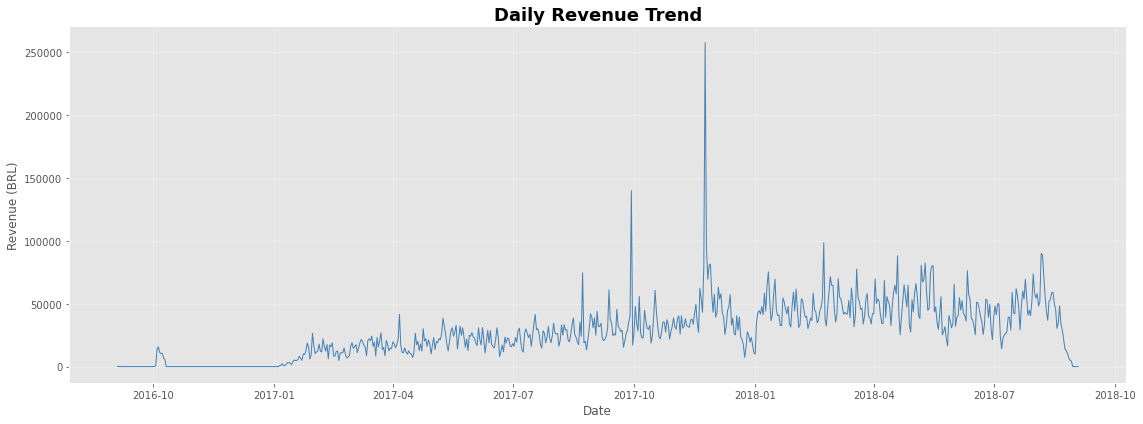

In [16]:
plt.figure(figsize=(16,6))

plt.plot(

    daily_sales.index,

    daily_sales["Revenue"],

    color="steelblue",

    linewidth=1

)

plt.title(

    "Daily Revenue Trend",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Date")

plt.ylabel("Revenue (BRL)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Moving Averages

In [17]:

daily_sales["MA7"] = (

    daily_sales["Revenue"]

    .rolling(7)

    .mean()

)

daily_sales["MA30"] = (

    daily_sales["Revenue"]

    .rolling(30)

    .mean()

)

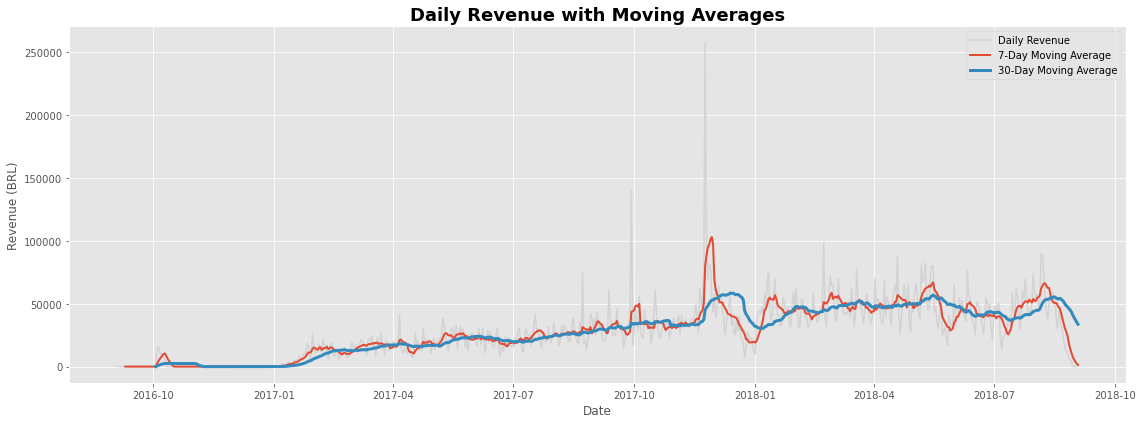

In [18]:
plt.figure(figsize=(16,6))

plt.plot(

    daily_sales.index,

    daily_sales["Revenue"],

    color="lightgray",

    label="Daily Revenue"

)

plt.plot(

    daily_sales.index,

    daily_sales["MA7"],

    linewidth=2,

    label="7-Day Moving Average"

)

plt.plot(

    daily_sales.index,

    daily_sales["MA30"],

    linewidth=3,

    label="30-Day Moving Average"

)

plt.title(

    "Daily Revenue with Moving Averages",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Date")

plt.ylabel("Revenue (BRL)")

plt.legend()

plt.tight_layout()

plt.show()

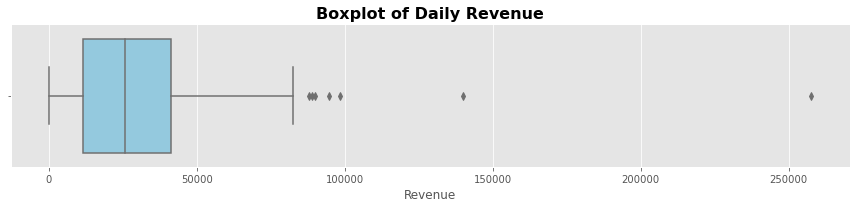

In [19]:
plt.figure(figsize=(12,3))

sns.boxplot(

    x=daily_sales["Revenue"],

    color="skyblue"

)

plt.title(

    "Boxplot of Daily Revenue",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

## Train-Test Split

In [20]:

# ==========================================================
# Chronological Train-Test Split
# ==========================================================

series = daily_sales["Revenue"]

train_size = int(len(series) * 0.80)

train = series.iloc[:train_size]

test = series.iloc[train_size:]

print("Training observations :", len(train))

print("Testing observations  :", len(test))

Training observations : 584
Testing observations  : 146


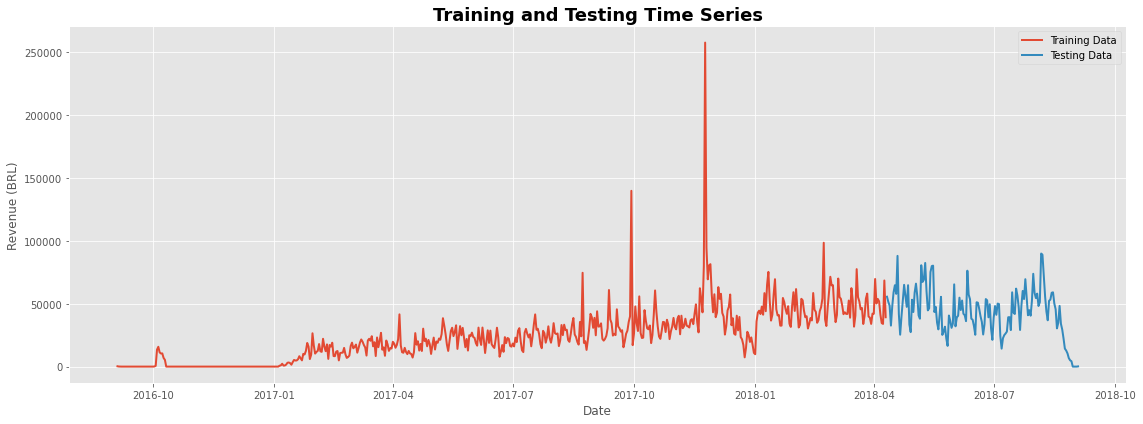

In [21]:
plt.figure(figsize=(16,6))

plt.plot(

    train,

    label="Training Data",

    linewidth=2

)

plt.plot(

    test,

    label="Testing Data",

    linewidth=2

)

plt.title(

    "Training and Testing Time Series",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Date")

plt.ylabel("Revenue (BRL)")

plt.legend()

plt.tight_layout()

plt.show()

## Persistence Baseline Forecast

The persistence (naïve) model assumes that the revenue for the next day will be the same as the revenue observed on the previous day.

Although simple, it serves as an important benchmark. Any forecasting model should outperform this baseline to justify its increased complexity.

In [22]:
# ==========================================================
# Persistence (Naïve) Forecast
# ==========================================================

history = train.copy()

predictions = []

for actual in test:

    # Predict today's revenue using yesterday's revenue
    predictions.append(history.iloc[-1])

    # Update history with the actual observed value
    history = pd.concat(
        [
            history,
            pd.Series([actual], index=[test.index[len(predictions)-1]])
        ]
    )

predictions = pd.Series(
    predictions,
    index=test.index
)

In [23]:
# ==========================================================
# Baseline Evaluation
# ==========================================================

baseline_mae = mean_absolute_error(
    test,
    predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test,
        predictions
    )
)

mask = test != 0

baseline_mape = np.mean(
    np.abs(
        (test[mask] - predictions[mask]) / test[mask]
    )
) * 100

baseline_r2 = r2_score(
    test,
    predictions
)

baseline_results = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "MAPE (%)",
        "R²"
    ],

    "Persistence":[

        baseline_mae,

        baseline_rmse,

        baseline_mape,

        baseline_r2

    ]

})

baseline_results.round(2)

,Metric,Persistence
0,MAE,11061.14
1,RMSE,14633.69
2,MAPE (%),27.69
3,R²,0.39


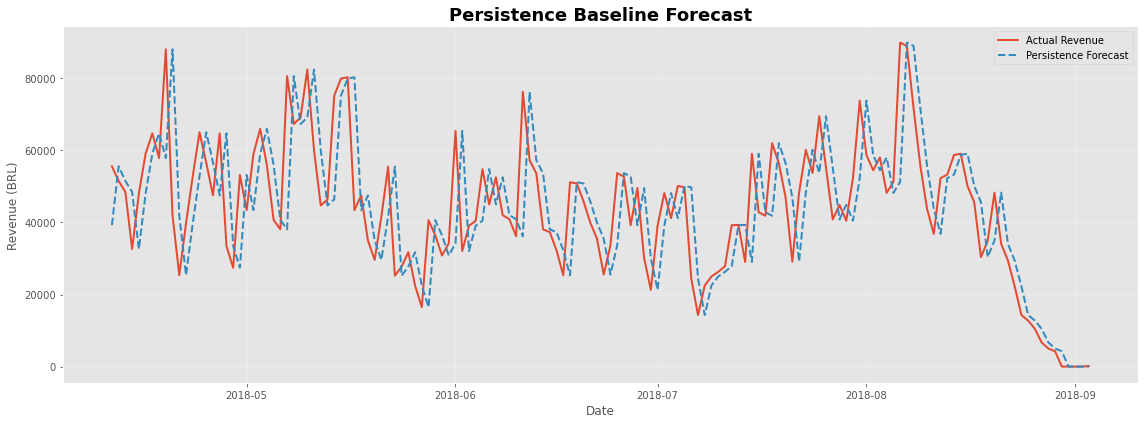

In [24]:
plt.figure(figsize=(16,6))

plt.plot(
    test.index,
    test,
    label="Actual Revenue",
    linewidth=2
)

plt.plot(
    predictions.index,
    predictions,
    label="Persistence Forecast",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Persistence Baseline Forecast",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Revenue (BRL)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Stationarity Test

ARIMA assumes that the input time series is stationary.

The Augmented Dickey-Fuller (ADF) test is used to determine whether the daily revenue series is stationary.

- **Null hypothesis (H₀):** The series is non-stationary.
- **Alternative hypothesis (H₁):** The series is stationary.

A p-value less than 0.05 indicates that the null hypothesis can be rejected.

In [25]:
# ==========================================================
# Augmented Dickey-Fuller Test
# ==========================================================

adf_result = adfuller(train)

print("="*50)
print("Augmented Dickey-Fuller Test")
print("="*50)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"P-value       : {adf_result[1]:.6f}")

print("\nCritical Values")

for key, value in adf_result[4].items():

    print(f"{key}: {value:.4f}")

Augmented Dickey-Fuller Test
ADF Statistic : -2.5683
P-value       : 0.099725

Critical Values
1%: -3.4417
5%: -2.8666
10%: -2.5694


In [26]:
alpha = 0.05

if adf_result[1] < alpha:

    print("Conclusion:")
    print("The series is stationary.")
    print("Differencing is NOT required.")

else:

    print("Conclusion:")
    print("The series is NOT stationary.")
    print("Differencing is required.")

Conclusion:
The series is NOT stationary.
Differencing is required.


In [27]:
# ==========================================================
# First Difference
# ==========================================================

train_diff = train.diff().dropna()

train_diff.head()

Date
2016-09-05   -197.40
2016-09-06    -75.06
2016-09-07      0.00
2016-09-08      0.00
2016-09-09      0.00
Freq: D, Name: Revenue, dtype: float64

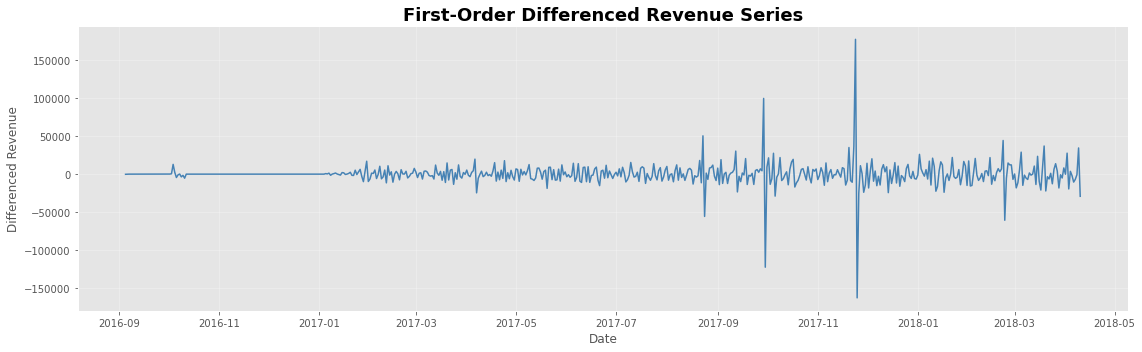

In [28]:
plt.figure(figsize=(16,5))

plt.plot(
    train_diff,
    color="steelblue"
)

plt.title(
    "First-Order Differenced Revenue Series",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Differenced Revenue")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [29]:
adf_diff = adfuller(train_diff)

print("="*50)
print("ADF Test After First Differencing")
print("="*50)

print(f"ADF Statistic : {adf_diff[0]:.4f}")
print(f"P-value       : {adf_diff[1]:.6f}")

print("\nCritical Values")

for key, value in adf_diff[4].items():

    print(f"{key}: {value:.4f}")

ADF Test After First Differencing
ADF Statistic : -17.1851
P-value       : 0.000000

Critical Values
1%: -3.4417
5%: -2.8666
10%: -2.5694


In [30]:
if adf_diff[1] < 0.05:

    print("The differenced series is stationary.")
    print("ARIMA parameter d = 1")

else:

    print("Further differencing may be required.")

The differenced series is stationary.
ARIMA parameter d = 1


## Autocorrelation Function (ACF)

The ACF plot helps identify the Moving Average (MA) order (**q**) by showing the correlation between observations at different lags.

<Figure size 864x360 with 0 Axes>

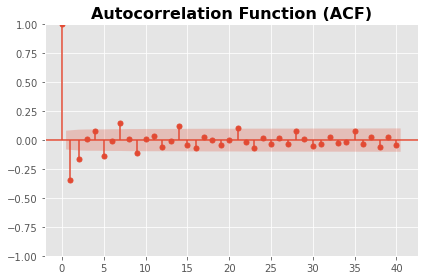

In [31]:
plt.figure(figsize=(12,5))

plot_acf(
    train_diff,
    lags=40
)

plt.title(
    "Autocorrelation Function (ACF)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Partial Autocorrelation Function (PACF)

The PACF plot helps identify the Autoregressive (AR) order (**p**) by measuring the direct relationship between observations after accounting for intermediate lags.

<Figure size 864x360 with 0 Axes>

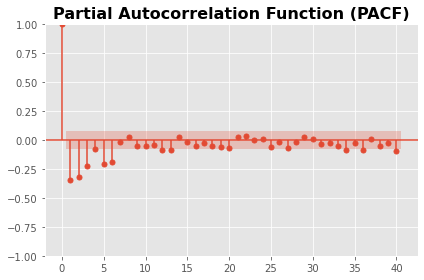

In [32]:
plt.figure(figsize=(12,5))

plot_pacf(
    train_diff,
    lags=40,
    method="ywm"
)

plt.title(
    "Partial Autocorrelation Function (PACF)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Candidate ARIMA Models

- Instead of guessing a single model, define several candidates for comparison.

In [33]:
# ==========================================================
# Candidate ARIMA Models
# ==========================================================

candidate_orders = [

    (1,1,1),

    (2,1,1),

    (1,1,2),

    (2,1,2),

    (3,1,1),

    (3,1,2)

]

candidate_orders

[(1, 1, 1), (2, 1, 1), (1, 1, 2), (2, 1, 2), (3, 1, 1), (3, 1, 2)]

## ARIMA Model Selection

Several ARIMA models are fitted and evaluated. Model selection is based on:

- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- Coefficient of Determination (R²)

The model with the lowest forecasting error and lowest information criteria is selected.

In [34]:
# ==========================================================
# Fit Candidate Models
# ==========================================================

model_results = []

fitted_models = {}

for order in candidate_orders:

    try:

        model = ARIMA(
            train,
            order=order
        )

        fitted = model.fit()

        forecast = fitted.forecast(
            steps=len(test)
        )

        mae = mean_absolute_error(
            test,
            forecast
        )

        rmse = np.sqrt(
            mean_squared_error(
                test,
                forecast
            )
        )

        mask = test != 0

        mape = np.mean(

            np.abs(

                (test[mask] - forecast[mask])

                /

                test[mask]

            )

        ) * 100

        r2 = r2_score(
            test,
            forecast
        )

        model_results.append({

            "Order": order,

            "AIC": fitted.aic,

            "BIC": fitted.bic,

            "MAE": mae,

            "RMSE": rmse,

            "MAPE": mape,

            "R2": r2

        })

        fitted_models[order] = fitted

    except Exception as e:

        print(order, e)

## Compare Models

In [35]:
#Compare Models
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(

    by="RMSE"

)

results_df.round(2)

,Order,AIC,BIC,MAE,RMSE,MAPE,R2
5,"(3, 1, 2)",12719.14,12745.35,14671.71,18940.94,246.43,-0.02
1,"(2, 1, 1)",12717.22,12734.69,14677.65,18950.96,246.90,-0.02
2,"(1, 1, 2)",12715.77,12733.24,14679.72,18954.64,247.04,-0.02
3,"(2, 1, 2)",12717.55,12739.39,14679.74,18954.68,247.04,-0.02
0,"(1, 1, 1)",12716.38,12729.48,14699.31,18992.73,248.80,-0.02
4,"(3, 1, 1)",12715.68,12737.52,14757.06,19090.96,252.07,-0.03


## Best Model

In [36]:
# Best Model
best_order = results_df.iloc[0]["Order"]

best_order

(3, 1, 2)

In [37]:
best_model = fitted_models[best_order]

print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  584
Model:                 ARIMA(3, 1, 2)   Log Likelihood               -6353.569
Date:                Thu, 09 Jul 2026   AIC                          12719.138
Time:                        12:02:18   BIC                          12745.347
Sample:                    09-04-2016   HQIC                         12729.353
                         - 04-10-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6643      0.327     -2.029      0.042      -1.306      -0.023
ar.L2          0.1513      0.108      1.403      0.161      -0.060       0.363
ar.L3         -0.0666      0.057     -1.169      0.2

In [57]:
import os
import joblib

# Create models folder if it doesn't exist
os.makedirs("/models", exist_ok=True)

# Save the best ARIMA model
joblib.dump(
    best_model,
    "arima_model.pkl"
)

print("ARIMA model saved successfully.")

ARIMA model saved successfully.


In [58]:
import os

print(os.path.exists("arima_model.pkl"))

True


In [59]:
loaded_model = joblib.load("arima_model.pkl")

print(type(loaded_model))

<class 'statsmodels.tsa.arima.model.ARIMAResultsWrapper'>


In [60]:
forecast = best_model.forecast(steps=30)

forecast.to_csv(
    "arima_forecast.csv",
    header=["Forecast"]
)

print("Forecast saved successfully.")

Forecast saved successfully.


## Forecast Test Period

In [38]:
#Forecast Test Period
forecast = best_model.forecast(
    steps=len(test)
)

forecast = pd.Series

In [39]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(p,d,q)
model = ARIMA(train, order=(3,1,2))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  584
Model:                 ARIMA(3, 1, 2)   Log Likelihood               -6353.569
Date:                Thu, 09 Jul 2026   AIC                          12719.138
Time:                        12:13:27   BIC                          12745.347
Sample:                    09-04-2016   HQIC                         12729.353
                         - 04-10-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6643      0.327     -2.029      0.042      -1.306      -0.023
ar.L2          0.1513      0.108      1.403      0.161      -0.060       0.363
ar.L3         -0.0666      0.057     -1.169      0.2

## Forecast the Test Data

In [40]:

forecast = model_fit.forecast(steps=len(test))

## Evaluate 

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

mask = test != 0

mape = np.mean(
    np.abs((test[mask] - forecast[mask]) / test[mask])
) * 100

r2 = r2_score(test, forecast)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

MAE  : 14671.71
RMSE : 18940.94
MAPE : 246.43%
R²   : -0.0153


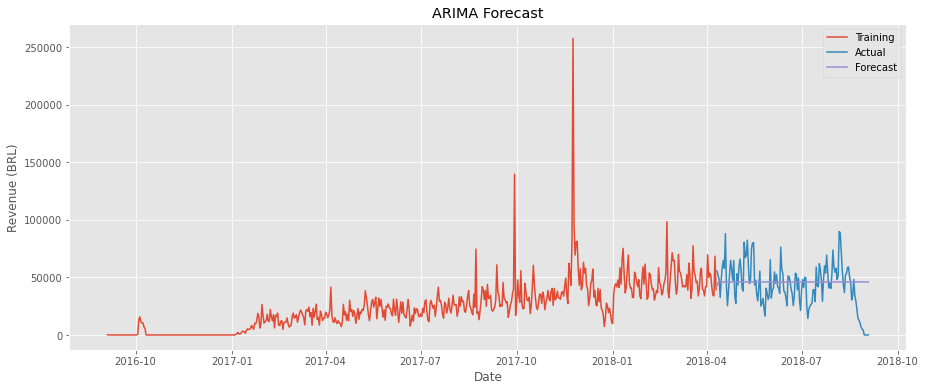

In [42]:
plt.figure(figsize=(15,6))

plt.plot(train.index,
         train,
         label="Training")

plt.plot(test.index,
         test,
         label="Actual")

plt.plot(test.index,
         forecast,
         label="Forecast")

plt.title("ARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Revenue (BRL)")

plt.legend()

plt.grid(True)

plt.show()

## Residual Analysis

In [43]:
#Residual Analysis
residuals = test - forecast

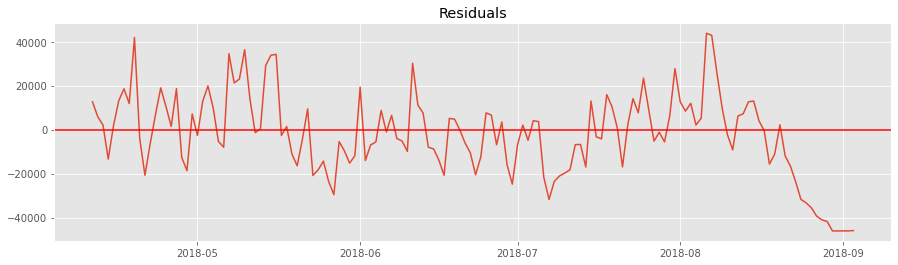

In [44]:
plt.figure(figsize=(15,4))

plt.plot(residuals)

plt.axhline(0,color="red")

plt.title("Residuals")

plt.show()

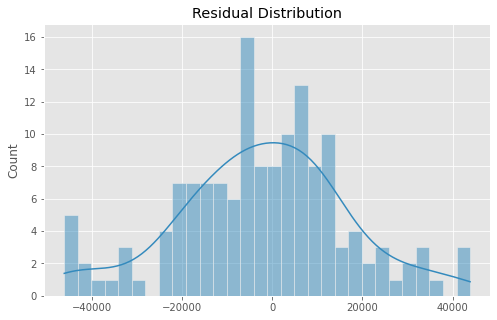

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(residuals,
             bins=30,
             kde=True)

plt.title("Residual Distribution")

plt.show()

## Forecast the Next 30 Days

In [46]:
#Forecast the Next 30 Days
future_forecast = model_fit.forecast(steps=30)

## Create Future Dates

In [47]:
#Create Future Dates
future_dates = pd.date_range(

    start=test.index[-1] + pd.Timedelta(days=1),

    periods=30,

    freq="D"

)

In [49]:
future_df = pd.DataFrame({

    "Date": future_dates,

    "Forecast_Revenue": future_forecast

})

future_df.head()

,Date,Forecast_Revenue
2018-04-11,2018-09-04,42952.187558
2018-04-12,2018-09-05,45628.980324
2018-04-13,2018-09-06,46355.100357
2018-04-14,2018-09-07,46031.819258
2018-04-15,2018-09-08,46178.205551


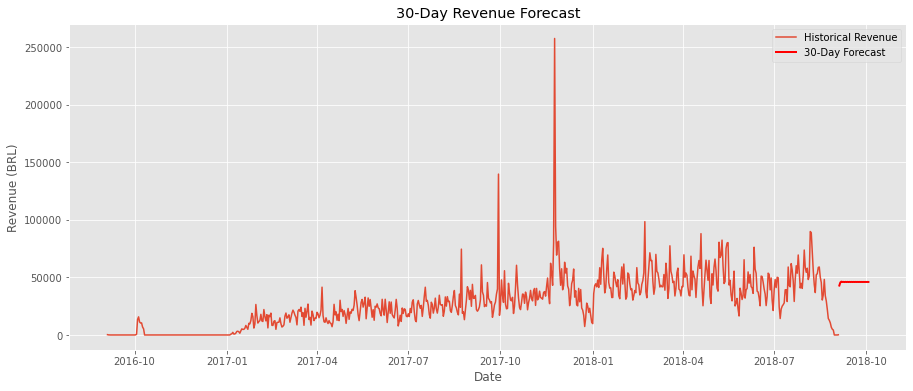

In [50]:
plt.figure(figsize=(15,6))

plt.plot(series,
         label="Historical Revenue")

plt.plot(future_df["Date"],
         future_df["Forecast_Revenue"],
         color="red",
         linewidth=2,
         label="30-Day Forecast")

plt.title("30-Day Revenue Forecast")

plt.xlabel("Date")

plt.ylabel("Revenue (BRL)")

plt.legend()

plt.grid(True)

plt.show()

## Save Forecast

In [51]:
future_df.to_csv(
    "arima_30day_forecast.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.


In [52]:
import os

os.makedirs("/models", exist_ok=True)
os.makedirs("/data", exist_ok=True)

In [1]:
import joblib

joblib.dump(
    model_fit,
    "/models/arima_model.pkl"
)

print("ARIMA model saved successfully.")

NameError: name 'model_fit' is not defined

In [54]:
daily_sales.to_csv(
    "/data/daily_sales.csv"
)

print("Historical daily sales saved.")

Historical daily sales saved.


### 

### 